# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [54]:
import numpy as np
import matplotlib.pyplot as plt

In [55]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [56]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

# Toevoegen van een zwaar deeltje in he centrum
particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 


```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
```

```{solution} ex-brownian-1
Er wordt een deeltje toegevoegd met: een massa van 20.0, een snelheid van 0, een positie op (0,0), een straal van 0.5 en een rode kleur. Dit is een soort zware centrale massa.
```

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 



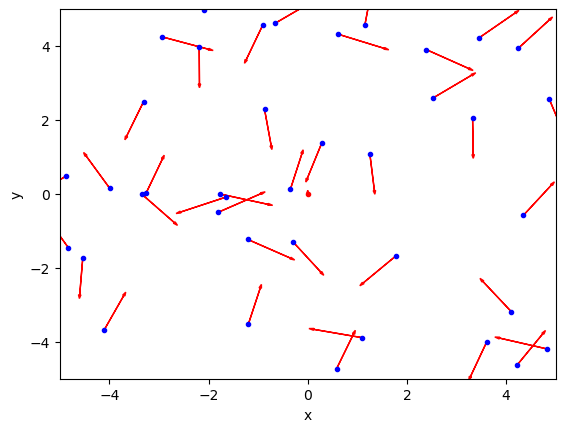

In [57]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    plt.arrow(particle_object.r[0],particle_object.r[1], 
               particle_object.v[0],particle_object.v[1], 
               head_width=0.05, head_length=0.1, color='red')
plt.show()


```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Hij laat de snelheidsvector zien.

Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

```{solution} ex-brownian-2
De vy van elk deeltje wordt zo gekozen dat de grootte van elke snelheidsvector precies gelijk is aan v0.
```

We gaan nu de functies van de simulatie weer aanroepen:

In [58]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
#your code/answer
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
#your code/answer


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

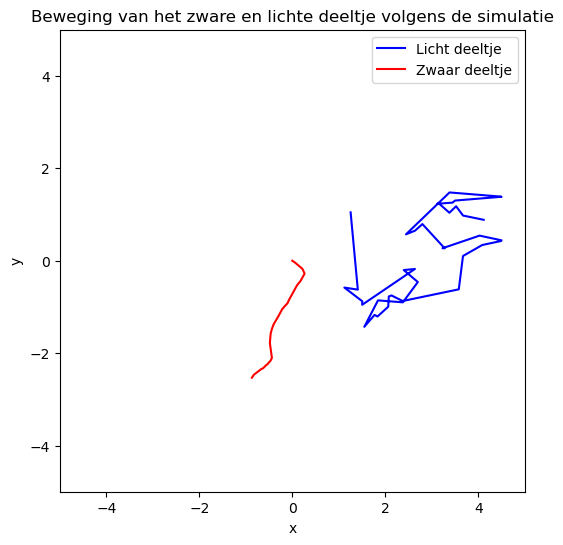

In [59]:
# tracken van het zware deeltje
track_x = []
track_y = []

#tracken van een licht deeltje
light_particle_index = 0  # Index van het lichte deeltje om te volgen
track_x_light = []
track_y_light = []

for i in range(400):
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)

    track_x_light.append(particles[light_particle_index].r[0])
    track_y_light.append(particles[light_particle_index].r[1])

    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    

plt.figure(figsize=(6,6))
plt.plot(track_x_light,track_y_light,'b', label='Licht deeltje')
plt.plot(track_x,track_y,'r', label='Zwaar deeltje')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Beweging van het zware en lichte deeltje volgens de simulatie')
plt.legend()
plt.show()

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?

```

```{solution} ex-brownian-3
-De output geeft de baan weer van het zware deeltje en verandert bij elke run.
-Tussen de botsingen hebben beide deeltjes rechte stukken en zweven beide rond door de box op geheel willekeurige wijze door de vele botsingen. Het lichte deeltje heeft een veel grotere afstanden afgelegd door de hogere snelheden die die standaard heeft (het zware deeltje begint met v=0).
-De banen die beide deeltjes volgen zijn compleet willekeurig en verschillen bij elke run.


```

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

In [74]:
def handle_collisions(particles):
    """ Handelt alle botsingen af en telt alleen echte botsingen (waarbij snelheden zullen veranderen) """
    num_particles = len(particles)
    collision_count = 0

    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                
                #snelheden voor de botsing opslaan
                v1_before = particles[i].v.copy()
                v2_before = particles[j].v.copy()

                #botsing afhandelen
                particle_collision(particles[i], particles[j])

                #alleen tellen als de snelheden daadwerkelijk zijn veranderd
                if not (np.array_equal(v1_before, particles[i].v) and np.array_equal(v2_before, particles[j].v)):
                    collision_count += 1
    return collision_count

total_collisions = 0
n_steps = 400

for i in range(n_steps):
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    total_collisions += handle_collisions(particles)

print(f"Totaal aantal echte botsingen is: {total_collisions}")

Totaal aantal echte botsingen is: 548


```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


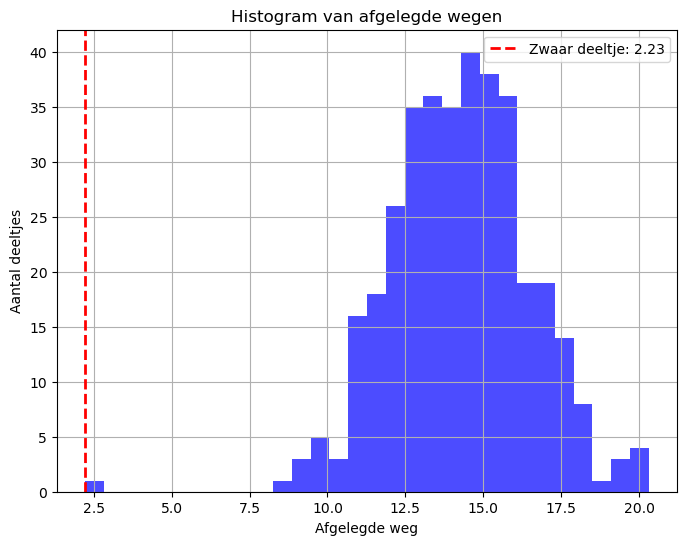

In [75]:
# Schalen van de box en aantal deeltjes
N = 361 #360 lichte deeltjes + 1 zwaar deeltje
N_oud = 40 #referentie naar vorige simulatie
Box_size_0 = 10
Box_length_0 = Box_size_0/2

Box_length = Box_length_0 * np.sqrt(N/N_oud)

dt = 0.04
v_0 = 1
heavy_mass = 20.0
heavy_idx = N - 1

particles = []

#deeltjes aanmaken
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)
    pos = Box_length * np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue'))

#zwaar deeltje in het centrum toevoegen
particles.append(ParticleClass(m=heavy_mass, v=[0, 0], r = [0, 0], R=.5,c='red'))

#afgelegde weg per deeltje bijhouden
n_steps = 400
path_lengths = np.zeros(N)

#oude posities
prev_r = np.array([p.r.copy() for p in particles])

for i in range(n_steps):
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje

    current_r = np.array([p.r.copy() for p in particles])
    step_distances = np.linalg.norm(current_r - prev_r, axis=1)
    path_lengths += step_distances
    prev_r = current_r

    #onderlinge botsingen afhandelen
    handle_collisions(particles)

#histogram
heavy_path = path_lengths[heavy_idx]

plt.figure(figsize=(8,6))
plt.hist(path_lengths, bins=30, color='blue', alpha=0.7)
plt.axvline(heavy_path, color='red', linestyle='--', linewidth=2, label=f'Zwaar deeltje: {heavy_path:.2f}')
plt.xlabel('Afgelegde weg')
plt.ylabel('Aantal deeltjes')
plt.title('Histogram van afgelegde wegen')
plt.legend()
plt.grid(True)
plt.show()

En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

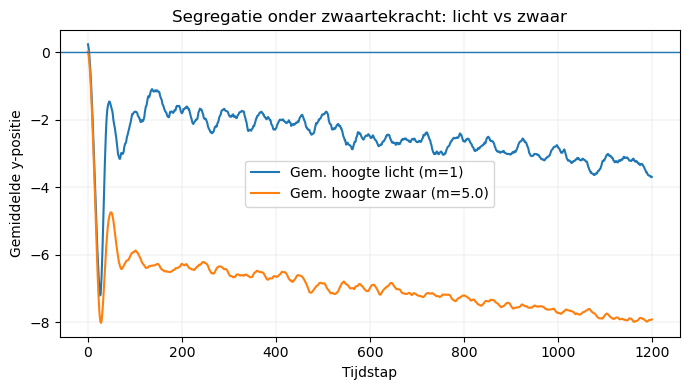

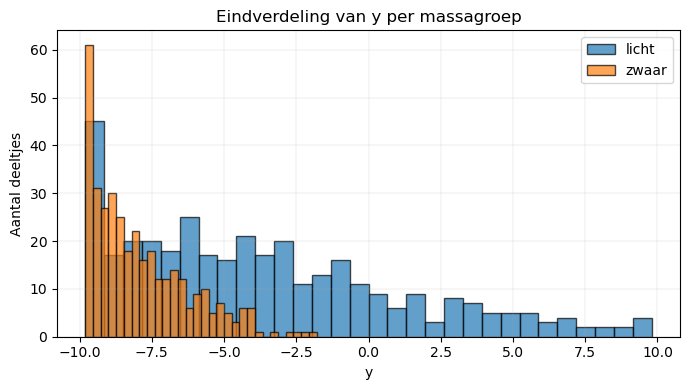

In [ ]:
#Deze code duurt een aantal minuten (het duurde bij mij 5.5 minuten), dit komt door de vele botsingen die moeten worden berekend.


#parameters
Box_size_0 = 10
Lx = Box_size_0 / 2
Ly = 2 * Lx

dt = 0.04
v_0 = 1.0

N = 722

# Twee groepen: licht en zwaar (je kunt de verhouding aanpassen)
frac_light = 0.5
N_light = int((N) * frac_light)
N_heavy = N - N_light

m_light = 1.0
m_heavy = 5.0

g = 25.0 #artificieel grote zwaartekracht
R = 0.2 #straal deeltjes

#wandbotsingen
def boxcollision_rect(p, Lx, Ly):
    # links/rechts
    if p.r[0] - p.R < -Lx:
        p.r[0] = -Lx + p.R
        p.v[0] *= -1
    elif p.r[0] + p.R > Lx:
        p.r[0] = Lx - p.R
        p.v[0] *= -1

    # onder/boven
    if p.r[1] - p.R < -Ly:
        p.r[1] = -Ly + p.R
        p.v[1] *= -1
    elif p.r[1] + p.R > Ly:
        p.r[1] = Ly - p.R
        p.v[1] *= -1

#twee groepen aanmaken
particles = []
labels = []  # 0 = light, 1 = heavy (voor analyse)

def random_velocity(v0):
    vx = np.random.uniform(-v0, v0)
    vy = np.random.choice([-1, 1]) * np.sqrt(max(0.0, v0**2 - vx**2))
    return np.array([vx, vy], dtype=float)

def random_position(Lx, Ly):
    return np.array([np.random.uniform(-Lx, Lx),
                     np.random.uniform(-Ly, Ly)], dtype=float)

# lichte deeltjes
for _ in range(N_light):
    particles.append(ParticleClass(m=m_light,
                                   v=random_velocity(v_0),
                                   r=random_position(Lx, Ly),
                                   R=R, c='blue'))
    labels.append(0)

# zware deeltjes
for _ in range(N_heavy):
    particles.append(ParticleClass(m=m_heavy,
                                   v=random_velocity(v_0),
                                   r=random_position(Lx, Ly),
                                   R=R, c='red'))
    labels.append(1)

labels = np.array(labels)

#simulatie met zwaartekracht
n_steps = 1200

mean_y_light = []
mean_y_heavy = []

for _ in range(n_steps):

    # (a) zwaartekracht: v_y <- v_y - g*dt
    for p in particles:
        p.v[1] -= g * dt

    # (b) positie-update + rechthoekige wandbotsingen
    for p in particles:
        p.update_position()
        boxcollision_rect(p, Lx, Ly)

    # (c) onderlinge botsingen
    handle_collisions(particles)

    # (d) metriek: gemiddelde hoogte per groep
    y = np.array([p.r[1] for p in particles])
    mean_y_light.append(np.mean(y[labels == 0]))
    mean_y_heavy.append(np.mean(y[labels == 1]))

#resultaten plotten
plt.figure(figsize=(7, 4))
plt.plot(mean_y_light, label='Gem. hoogte licht (m=1)')
plt.plot(mean_y_heavy, label=f'Gem. hoogte zwaar (m={m_heavy})')
plt.axhline(0, linewidth=1)
plt.xlabel('Tijdstap')
plt.ylabel('Gemiddelde y-positie')
plt.title('Segregatie onder zwaartekracht: licht vs zwaar')
plt.grid(True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#histogram van eindposities
y_end = np.array([p.r[1] for p in particles])

plt.figure(figsize=(7, 4))
plt.hist(y_end[labels == 0], bins=30, alpha=0.7, edgecolor='black', label='licht')
plt.hist(y_end[labels == 1], bins=30, alpha=0.7, edgecolor='black', label='zwaar')
plt.xlabel('y')
plt.ylabel('Aantal deeltjes')
plt.title('Eindverdeling van y per massagroep')
plt.grid(True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
